# Chapter 1: Hypothesis Testing - The Foundation of Everything
Before running any test, you must understand the framework all statistical tests share.
Every test follows this exact logic: you start by assuming nothing is happening (the null hypothesis H₀). Then you calculate how surprising your data would be under that assumption. If the data is surprising enough, you reject H₀ and conclude something real is going on.

In [1]:
import numpy as np , pandas as pd , matplotlib.pyplot as plt , seaborn as sns 
from scipy import stats

In [2]:
df = pd.read_csv('../data/titanic.csv')

##  Universal Structure of Every Hypothesis Test

---

###  Hypotheses

| Symbol | Name | Meaning |
|--------|------|---------|
| **H₀** | Null Hypothesis | "There is **NO** effect / difference / relationship" |
| **H₁** | Alternative Hypothesis | "There **IS** an effect / difference / relationship" |

---

###  Key Terms

| Term | Definition |
|------|------------|
| **Test Statistic** | A number measuring how far data is from H₀ |
| **p-value** | P(seeing data this extreme \| H₀ is true) |
| **Alpha (α)** | Your threshold, usually **0.05** |

---

###  Decision Rule

| Condition | Decision | Meaning |
|-----------|----------|---------|
| **p < α** |  Reject H₀ | Result is **statistically significant** |
| **p ≥ α** |  Fail to reject H₀ | Not enough evidence |

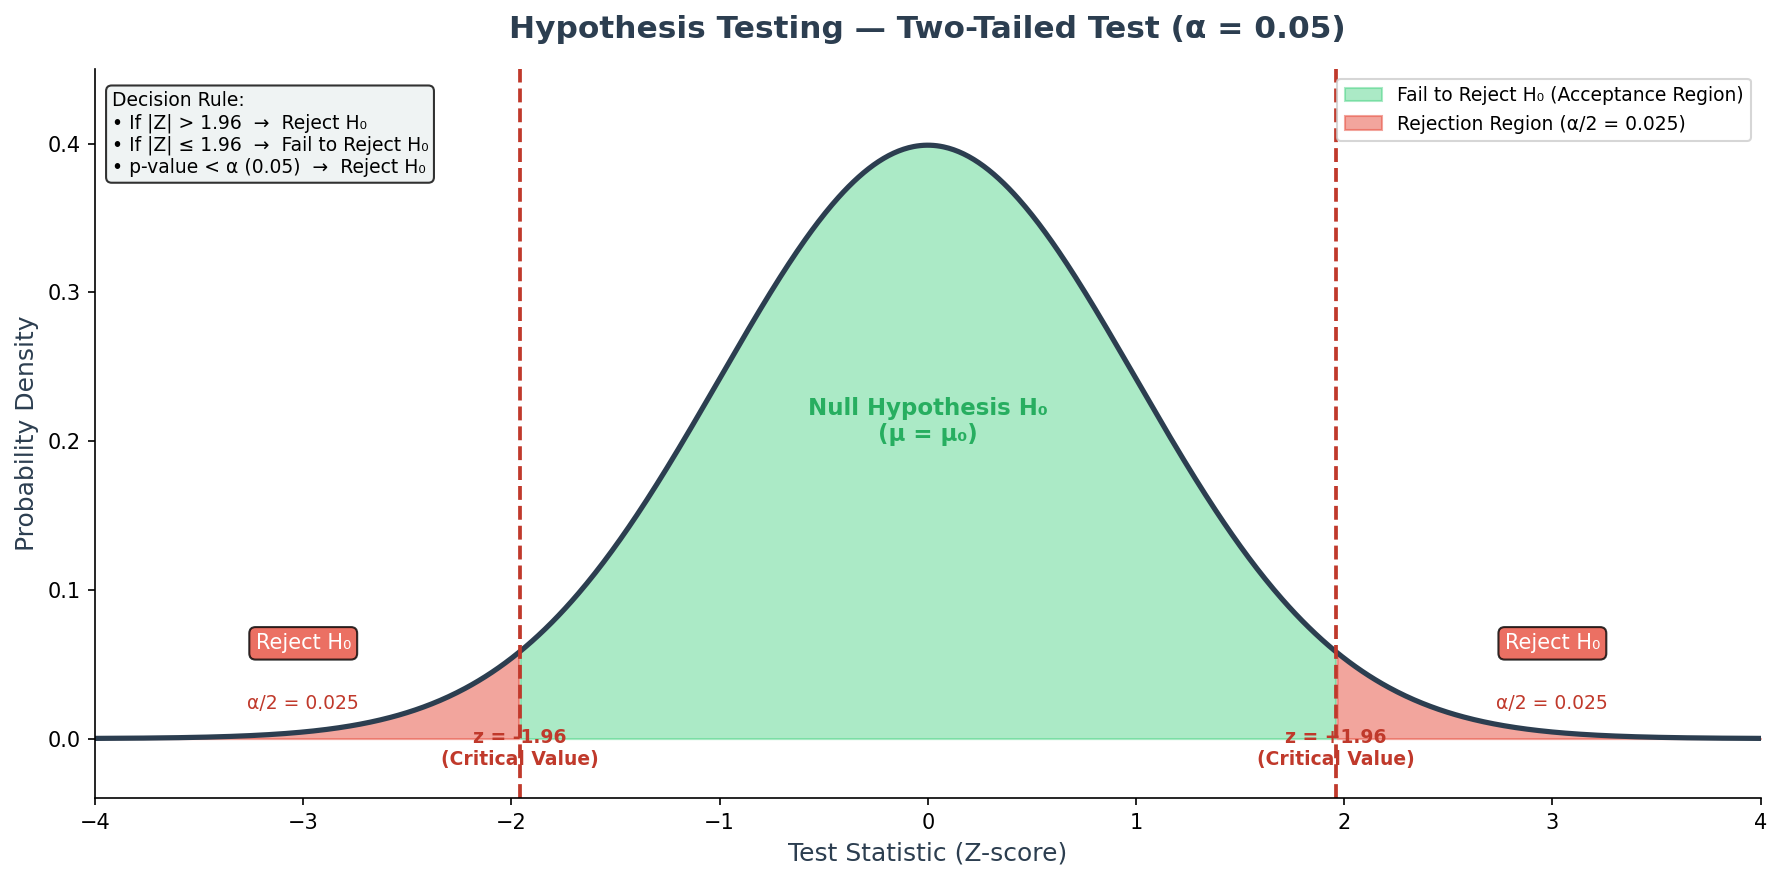

# Chapter 2: Normality Tests - The First Test You Always Run
Before choosing any other test, you must check: is your data normally distributed? The answer determines which tests are valid.

## Shapiro-Wilk Test — Best for Small to Medium Samples (n < 5000)

In [6]:
from scipy.stats import shapiro

# shapiro wilk test
age = df['Age'].dropna()
fare = df['Fare'].dropna()

stat_age , p_age = shapiro(age.sample(min(len(age) , 5000) , random_state= 32))
stat_fare , p_fare = shapiro(fare.sample(min(len(fare) , 5000) , random_state = 32))

print(f"age w = {stat_age:.4f} , p = {p_age:.4f}")
print(f"fare w = {stat_fare:.4f} , p = {p_fare:.6f}")


# H₀: data IS normally distributed
# H₁: data is NOT normally distributed
# p < 0.05 → REJECT H₀ → data is NOT normal
# p >= 0.05 → fail to reject → data could be normal

age w = 0.9815 , p = 0.0000
fare w = 0.5219 , p = 0.000000


## Kolmogorov-Smirnov Test — Best for Large Samples

ks test - stat = 0.0646 , p = 0.0050


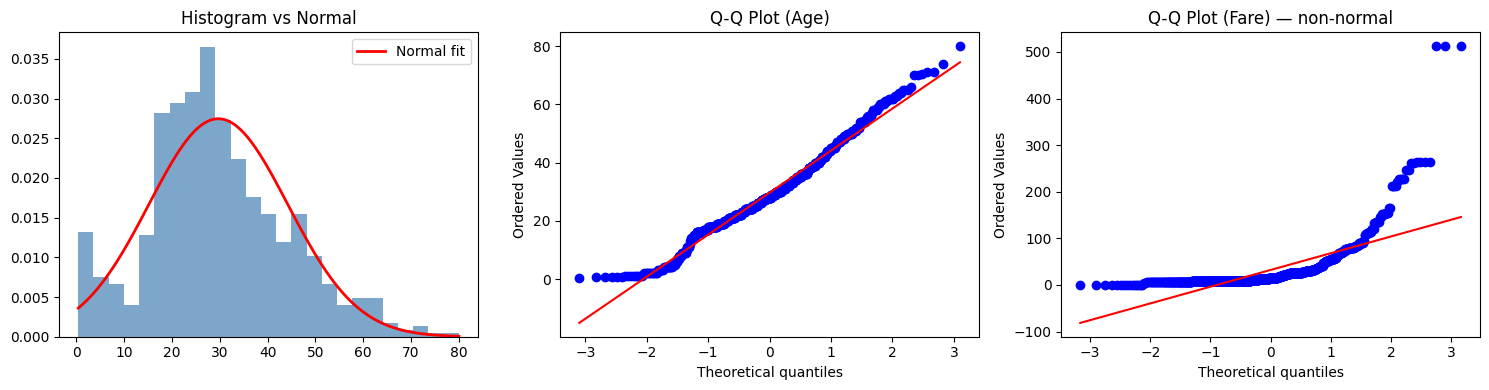

In [8]:
from scipy.stats import kstest , norm

# KS test compares the empirical CDF of your data
# to the theoretical CDF of a normal distribution 

age_standardised = (age - age.mean()) / age.std()
ks_stat , ks_p = kstest(age_standardised , 'norm')
print(f"ks test - stat = {ks_stat:.4f} , p = {ks_p:.4f}")

#  Visual normality checks (always pair with the test)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1 . Histogram + normal curve overlay
axes[0].hist(age, bins=25, density=True, alpha=0.7, color='steelblue')
xfit = np.linspace(age.min(), age.max(), 100)
axes[0].plot(xfit, norm.pdf(xfit, age.mean(), age.std()), 'r-', lw=2, label='Normal fit')
axes[0].set_title('Histogram vs Normal')
axes[0].legend()

# 2 . Q-Q Plot — the most powerful visual normality check
from scipy.stats import probplot
probplot(age, plot=axes[1])
axes[1].set_title('Q-Q Plot (Age)')

# 3. Q-Q Plot for Fare (non-normal)
probplot(fare, plot=axes[2])
axes[2].set_title('Q-Q Plot (Fare) — non-normal')

plt.tight_layout()
plt.show()


The Q-Q plot deserves special attention. If your data is normal, all points fall on the diagonal reference line. Any deviation tells you the shape of non-normality: points curving upward at both ends means heavy tails (kurtosis), a curve to one side means skew. Once you can read a Q-Q plot, you almost don't need the formal test.

In [ ]:
# what to do when data is not norml ? 
# option 1 : log transformation for right skewed data 
df['fare_log'] = np.log1p(df['Fare'])  # log1p = log(1 + x) -> handles zero

# option 2 : square root transformation moderate skew 
df['Age_sqrt'] = np.sqrt(df['Age'].dropna())


# Option 3: Use non-parametric tests (Mann-Whitney instead of t-test)
# — covered below

# Option 4: With n > 30, Central Limit Theorem kicks in
# → sample means are approximately normal even if raw data isn't
# → t-test is robust for large samples regardless of normality

# Chapter 3: t-Tests — Comparing Two Group Means
One-Sample t-Test - Is the Mean Equal to a Hypothesised Value?

In [10]:
# question : is the average titanic passengher age is 30 ? 

age = df['Age'].dropna()

t_stat , p_value = stats.ttest_1samp(age , popmean= 30)
print(f"Sample mean : {age.mean():.2f}")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value : {p_value:.4f}")

Sample mean : 29.70
t-statistic : -0.5535
p-value : 0.5801


 mean=29.70, p=0.71 → fail to reject H₀
 We cannot conclude the mean age differs from 30
 (it's close to 30 and variance is high) 

## Independent Two-Sample t-Test — Do Two Groups Have Different Means?
This is the most common test in EDA. You saw a boxplot showing different distributions — now you confirm it statistically.

In [11]:
# Visual finding: "Survivors look younger in the boxplot"
# Test: Is the age difference between survivors and non-survivors real? 

survived_age = df[df['Survived'] == 1]['Age'].dropna()
died_age = df[df['Survived'] == 0]['Age'].dropna()

print(f" survived mean age : {survived_age.mean():.2f}")
print(f"died mean age : {died_age.mean():.2f}")
print(f"difference : {survived_age.mean() - died_age.mean():.2f}")

# Step 1: Check equal variances (Levene's test)
lev_stat , lev_p = stats.levene(survived_age , died_age)
print(f"levenes test stat = {lev_stat:.4f} , p = {lev_p:.4f}")
equal_var = lev_p > 0.05    # True = assume equal variance 

# step 2 : run t - test
t_stat, p_val = stats.ttest_ind(survived_age, died_age, equal_var=equal_var)
print(f"\nIndependent t-test:")
print(f"t={t_stat:.4f}, p={p_val:.4f}")
print(f"{'Reject H₀' if p_val < 0.05 else 'Fail to reject H₀'}")


 survived mean age : 28.34
died mean age : 30.63
difference : -2.28
levenes test stat = 1.1954 , p = 0.2746

Independent t-test:
t=-2.0667, p=0.0391
Reject H₀


 p=0.039 → significant! Age distributions DO differ by survival status

## Paired t-Test — Same Group, Two Conditions

In [12]:
# Paired t-test: used when the SAME subjects are measured twice
# Example: blood pressure before and after treatment
# (Titanic doesn't have this, so here's a realistic template)

before = np.array([140, 138, 145, 132, 149, 155, 142, 138, 146, 151])
after  = np.array([135, 131, 140, 128, 143, 148, 138, 132, 141, 145])

t_stat, p_val = stats.ttest_rel(before, after)
print(f"Mean before treatment: {before.mean():.1f}")
print(f"Mean after treatment : {after.mean():.1f}")
print(f"Mean reduction       : {(before - after).mean():.1f}")
print(f"t={t_stat:.4f}, p={p_val:.4f}")

Mean before treatment: 143.6
Mean after treatment : 138.1
Mean reduction       : 5.5
t=16.1024, p=0.0000


p<0.001 -> treatment significantly reduced blood pressure

## Non-Parametric Alternative — Mann-Whitney U (When Data is Not Normal)

In [15]:
# Fare is heavily non-normal (right-skewed, outliers)
# For Fare : use Mann-Whitney instead of t-test

survived_fare = df[df['Survived']==1]['Fare'].dropna()
died_fare     = df[df['Survived']==0]['Fare'].dropna()

u_stat, p_mw = stats.mannwhitneyu(survived_fare, died_fare, alternative='two-sided')
print(f"Mann-Whitney U: stat={u_stat:.0f}, p={p_mw:.6f}")
print(f"Median fare — survived: EUROS  {survived_fare.median():.2f}")
print(f"Median fare — died    : EUROS  {died_fare.median():.2f}")

Mann-Whitney U: stat=129952, p=0.000000
Median fare — survived: EUROS  26.00
Median fare — died    : EUROS  10.50


 p << 0.001 → survivors paid significantly higher fares (higher class)

# Chapter 4: ANOVA - Comparing Three or More Group Means
When you have 3+ groups, running multiple t-tests inflates the Type I error rate (false positives). ANOVA tests all groups simultaneously.

In [16]:
# Visual finding: "Fare looks different across the 3 passenger classes"
# Test: Are mean fares significantly different across classes?

class1_fare = df[df['Pclass']==1]['Fare'].dropna()
class2_fare = df[df['Pclass']==2]['Fare'].dropna()
class3_fare = df[df['Pclass']==3]['Fare'].dropna()

# one way ANOVA 
f_stat, p_anova = stats.f_oneway(class1_fare, class2_fare, class3_fare)

print("One-Way ANOVA: Fare across Passenger Classes")
print(f"  Class 1 mean: £{class1_fare.mean():.2f}")
print(f"  Class 2 mean: £{class2_fare.mean():.2f}")
print(f"  Class 3 mean: £{class3_fare.mean():.2f}")
print(f"  F={f_stat:.4f}, p={p_anova:.2e}")

One-Way ANOVA: Fare across Passenger Classes
  Class 1 mean: £84.15
  Class 2 mean: £20.66
  Class 3 mean: £13.68
  F=242.3442, p=1.03e-84


F=116.6, p << 0.001 → VERY significant differences between classes

In [17]:
#  ANOVA tells you THAT groups differ, not WHICH ones
# Use Tukey HSD post-hoc test to find the specific pairs 
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

fare_data   = pd.concat([class1_fare, class2_fare, class3_fare])
class_labels = (['1st']*len(class1_fare) + ['2nd']*len(class2_fare)
               + ['3rd']*len(class3_fare))

tukey = pairwise_tukeyhsd(fare_data, class_labels, alpha=0.05)
print("\nTukey HSD Post-Hoc Test:")
print(tukey)


Tukey HSD Post-Hoc Test:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
   1st    2nd -63.4925   0.0 -72.9165 -54.0685   True
   1st    3rd -70.4791   0.0 -78.1489 -62.8094   True
   2nd    3rd  -6.9866 0.108 -15.1064   1.1331  False
-----------------------------------------------------


 All pairs (1-2, 1-3, 2-3) are significant
 Class 1 vs Class 3 has the biggest difference

In [18]:
# Non-parametric ANOVA: Kruskal-Wallis (for non-normal data)
kw_stat, kw_p = stats.kruskal(class1_fare, class2_fare, class3_fare)
print(f"\nKruskal-Wallis: H={kw_stat:.4f}, p={kw_p:.2e}")


Kruskal-Wallis: H=438.0437, p=7.59e-96


# Chapter 5: Chi-Square Test — Categorical vs Categorical
The chi-square test answers: "do two categorical variables occur together more (or less) often than expected by pure chance?"

In [19]:
# Visual finding: "Survival rate looks different by Sex"
# Test: Is the association between Sex and Survival statistically significant?

#  Step 1: Build the contingency table 
ct = pd.crosstab(df['Sex'], df['Survived'])
print("Observed frequencies:")
print(ct)
#          Survived    0    1
# Sex
# female             81  233
# male              468  109

#  Step 2: Chi-square test 
chi2, p, dof, expected = stats.chi2_contingency(ct)

print(f"\nChi-square statistic : {chi2:.4f}")
print(f"p-value  : {p:.2e}")
print(f"Degrees of freedom  : {dof}")
print(f"\nExpected frequencies (under H₀ of independence):")
print(pd.DataFrame(expected, index=['female','male'], columns=[0,1]).round(1))

Observed frequencies:
Survived    0    1
Sex               
female     81  233
male      468  109

Chi-square statistic : 260.7170
p-value  : 1.20e-58
Degrees of freedom  : 1

Expected frequencies (under H₀ of independence):
            0      1
female  193.5  120.5
male    355.5  221.5


 Expected shows what you'd see if there was NO relationship
 Comparing expected vs observed shows the gap the test is measuring

 p << 0.001 → Extremely significant association
 Sex and Survival are NOT independent

In [20]:
# Effect size: Cramér's V 
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"\nCramér's V: {cramers_v:.4f}")


Cramér's V: 0.5409


V=0.54 → strong association (>0.3 = strong, 0.1-0.3 = moderate, <0.1 = weak)

In [21]:
# Chi-square test for Pclass vs Survived
ct2 = pd.crosstab(df['Pclass'], df['Survived'])
chi2_2, p_2, dof_2, _ = stats.chi2_contingency(ct2)
print(f"\nPclass vs Survived: chi2={chi2_2:.1f}, p={p_2:.2e}")


Pclass vs Survived: chi2=102.9, p=4.55e-23


 ─ IMPORTANT: Chi-square assumptions
 1. Expected frequency in each cell >= 5 (check expected output above)
 2. Observations are independent
 3. Categorical data only (not for ordinal with many levels)
 If expected < 5 in any cell → use Fisher's exact test (for 2x2)

In [22]:
odds_ratio, fisher_p = stats.fisher_exact(ct)
print(f"\nFisher's exact test: OR={odds_ratio:.3f}, p={fisher_p:.2e}")


Fisher's exact test: OR=0.081, p=6.46e-60


# Chapter 6: Correlation Tests — Pearson, Spearman, Kendall
Each correlation test has a specific use case. Choosing the wrong one gives you the wrong answer.

In [23]:
age  = df['Age'].dropna()
fare = df.loc[df['Age'].notna(), 'Fare']

# ── Pearson r — linear relationship, assumes normality ───────
r_p, p_p = stats.pearsonr(age, fare)
print(f"Pearson r  = {r_p:.4f}, p = {p_p:.4f}")
# r=0.096, p=0.013 → very weak but statistically significant
# Use when: both variables are normal, relationship is linear

# ── Spearman ρ — rank-based, robust to outliers/non-normality ─
r_s, p_s = stats.spearmanr(age, fare)
print(f"Spearman ρ = {r_s:.4f}, p = {p_s:.4f}")
# ρ=0.114, p=0.003 → slightly stronger than Pearson
# The outlier fares pull Pearson down; Spearman is more stable
# Use when: data has outliers, is ordinal, or is non-normal

# ── Kendall τ — concordance-based, best for small samples ────
r_k, p_k = stats.kendalltau(age, fare)
print(f"Kendall τ  = {r_k:.4f}, p = {p_k:.4f}")
# τ is more conservative than Spearman
# Use when: n < 30, or you need robust ordinal correlation

# ── Point-Biserial — numerical vs binary (0/1) ───────────────
# Perfect for correlating a numerical column with a binary target
survived = df.loc[df['Age'].notna(), 'Survived']
r_pb, p_pb = stats.pointbiserialr(survived, age)
print(f"\nPoint-biserial (Survived vs Age): r={r_pb:.4f}, p={p_pb:.4f}")
# This is mathematically identical to Pearson for binary variables

# ── Comprehensive: all numerical columns at once ─────────────
num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Survived']
corr_df = df[num_cols].dropna()

print("\nPearson correlation matrix:")
print(corr_df.corr(method='pearson').round(3))

print("\nSpearman correlation matrix:")
print(corr_df.corr(method='spearman').round(3))

Pearson r  = 0.0961, p = 0.0102
Spearman ρ = 0.1351, p = 0.0003
Kendall τ  = 0.0932, p = 0.0002

Point-biserial (Survived vs Age): r=-0.0772, p=0.0391

Pearson correlation matrix:
            Age   Fare  SibSp  Parch  Survived
Age       1.000  0.096 -0.308 -0.189    -0.077
Fare      0.096  1.000  0.138  0.205     0.268
SibSp    -0.308  0.138  1.000  0.384    -0.017
Parch    -0.189  0.205  0.384  1.000     0.093
Survived -0.077  0.268 -0.017  0.093     1.000

Spearman correlation matrix:
            Age   Fare  SibSp  Parch  Survived
Age       1.000  0.135 -0.182 -0.254    -0.053
Fare      0.135  1.000  0.423  0.407     0.339
SibSp    -0.182  0.423  1.000  0.427     0.073
Parch    -0.254  0.407  0.427  1.000     0.156
Survived -0.053  0.339  0.073  0.156     1.000


##  Correlation Tests — Which One to Use?

| Test | Use When | Assumes | Titanic Example |
|------|----------|---------|-----------------|
| **Pearson r** | Both normal, linear relationship, no outliers | Normality, linearity, no extreme outliers | Age vs SibSp (r = −0.31) |
| **Spearman ρ** | Non-normal, outliers present, ordinal data | Monotonic relationship, independent observations | Fare vs Survived (outlier fares) |
| **Kendall τ** | Small samples (n < 30), ordinal data, ties present | Ordinal or continuous, independent pairs | Pclass vs Survived (ordinal × binary) |
| **Point-biserial** | One continuous, one binary (0/1) variable | Continuous variable is roughly normal | Age vs Survived (0/1 target) |

# Chapter 7: The Master Decision Tree - Which Test to Use When

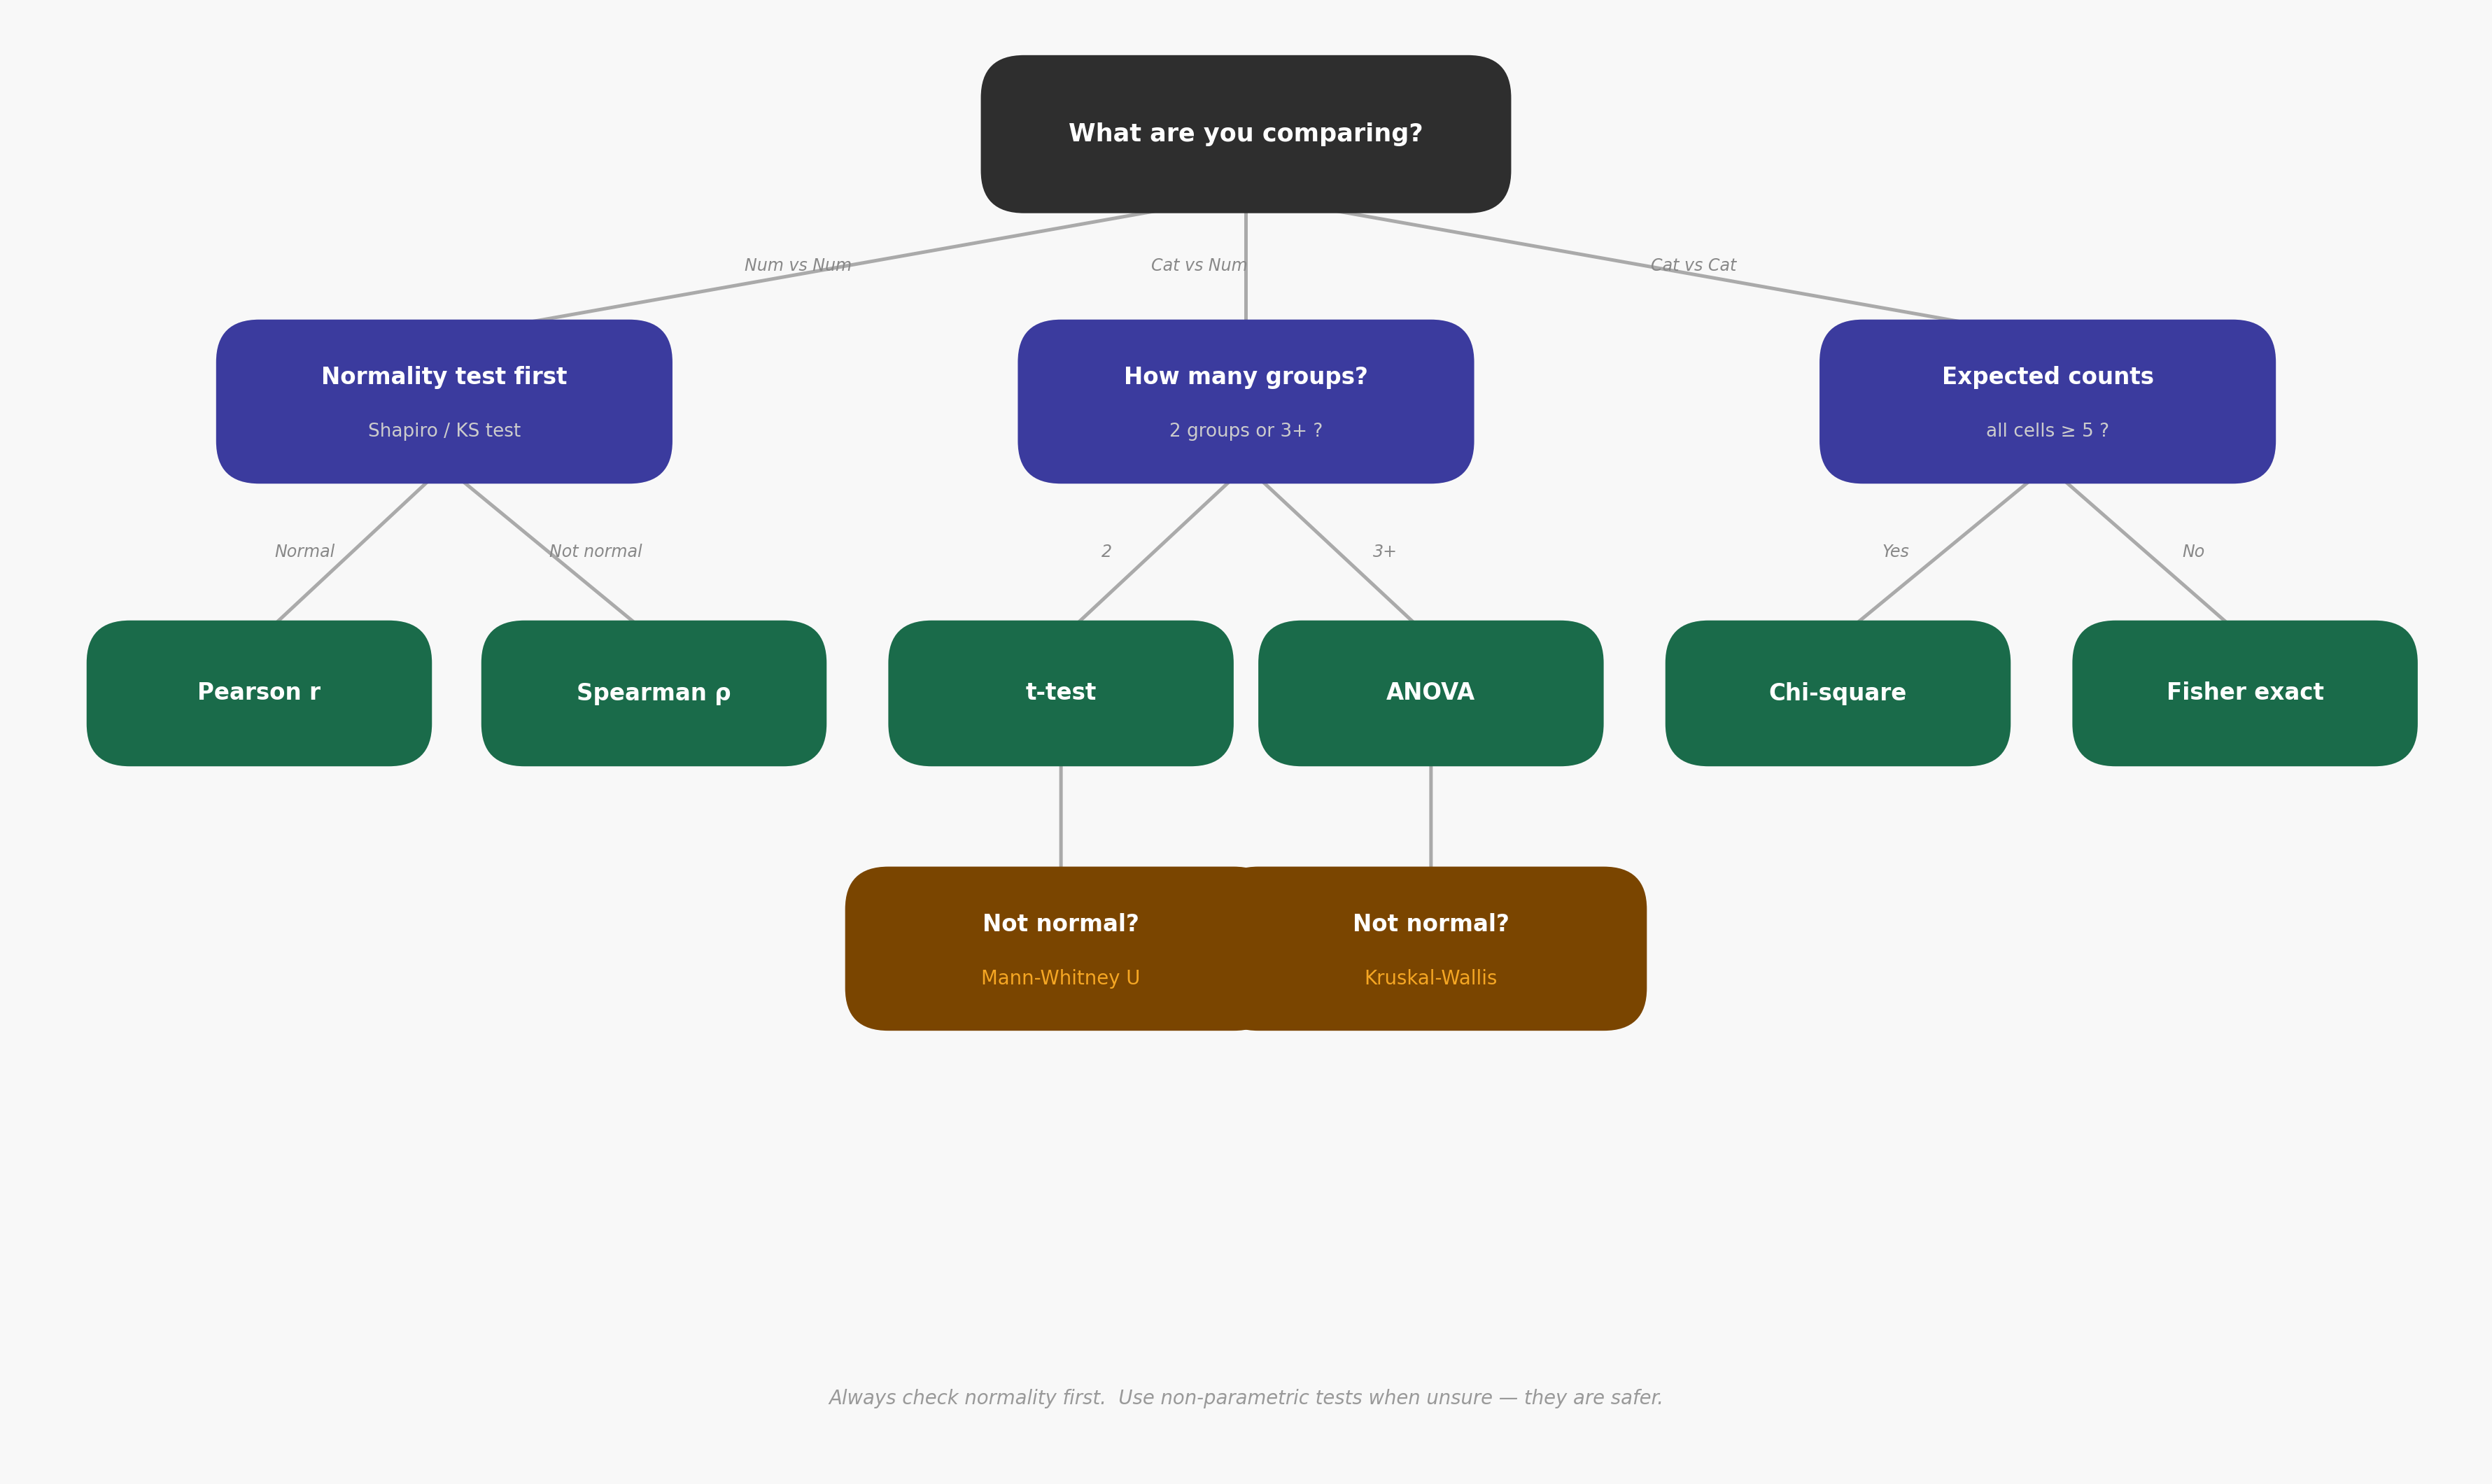

# END OF notebook 5